<a href="https://colab.research.google.com/github/vunnampragathi/PhDAI-731/blob/main/project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q ucimlrepo optuna pymc arviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.9 MB/s eta 0:00:00


Import libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    classification_report
)

import optuna

import pymc as pm
import arviz as az

RANDOM_STATE = 42

Load the UCI Heart Disease dataset

In [3]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features.copy()
y_original = heart_disease.data.targets.copy()

print("Dataset shape:", X.shape)
print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget preview:")
print(y_original.head())

Dataset shape: (303, 13)

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target preview:
   num
0    0
1    2
2    1
3    0
4    0


Examine the dataset

In [4]:
print("\nDataset information:")
print(X.info())

print("\nFirst five records:")
print(X.head())

print("\nDescriptive statistics:")
print(X.describe(include="all"))

print("\nMissing values:")
print(X.isnull().sum())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB
None

First five records:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2   

In [5]:
print(y_original.value_counts(dropna=False))

num
0      164
1       55
2       36
3       35
4       13
Name: count, dtype: int64


Create a binary heart-disease target
The original target has values:
0 = no heart disease
1, 2, 3, 4 = heart disease present


In [6]:
y_raw = y_original.iloc[:, 0]

y = (pd.to_numeric(y_raw, errors="coerce") > 0).astype(int)

print(y.value_counts())
print("\nDisease prevalence:")
print(y.value_counts(normalize=True))

num
0    164
1    139
Name: count, dtype: int64

Disease prevalence:
num
0    0.541254
1    0.458746
Name: proportion, dtype: float64


Convert all predictors to numeric

Some missing observations may appear as strings depending on how the data are imported.

In [7]:
X = X.apply(pd.to_numeric, errors="coerce")

In [8]:
print(X.dtypes)
print("\nMissing values:")
print(X.isnull().sum())

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64


Explore class distribution

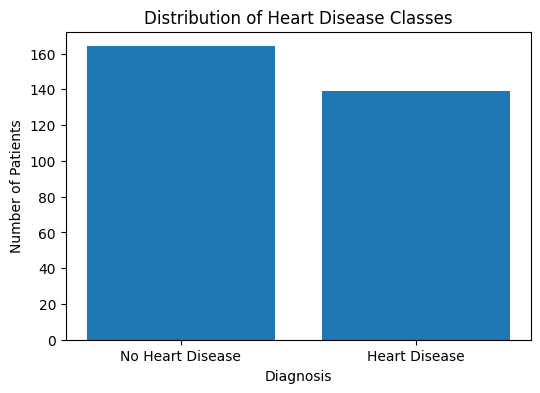

In [9]:
class_counts = y.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["No Heart Disease", "Heart Disease"], class_counts.values)
plt.title("Distribution of Heart Disease Classes")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.show()

Optional feature distributions

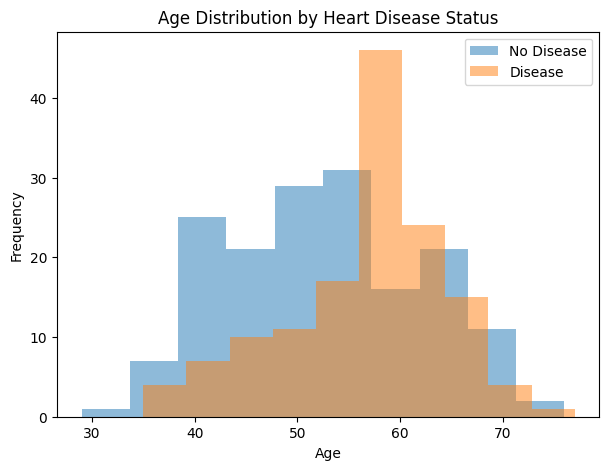

In [10]:
plt.figure(figsize=(7, 5))

for disease_value, label in [(0, "No Disease"), (1, "Disease")]:
    subset = X.loc[y == disease_value, "age"].dropna()
    plt.hist(subset, alpha=0.5, label=label)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution by Heart Disease Status")
plt.legend()
plt.show()

Train-test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 242
Testing samples: 61

Training class distribution:
num
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Testing class distribution:
num
0    0.540984
1    0.459016
Name: proportion, dtype: float64


Baseline Random Forest Model

Random Forest is an ensemble technique that builds multiple decision trees and combines their predictions. This generally provides better generalization and greater robustness than relying on a single decision tree.

We also need to prevent leakage.

The imputer therefore goes inside the pipeline.

In [12]:
baseline_rf = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        )
    )
])

baseline_rf.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

Baseline predictions

In [13]:
baseline_pred = baseline_rf.predict(X_test)

baseline_prob = baseline_rf.predict_proba(X_test)[:, 1]

Baseline evaluation

In [14]:
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)
baseline_auc = roc_auc_score(y_test, baseline_prob)

print("BASELINE RANDOM FOREST")
print("-" * 40)

print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")
print(f"ROC-AUC  : {baseline_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, baseline_pred))

BASELINE RANDOM FOREST
----------------------------------------
Accuracy : 0.9180
Precision: 0.8710
Recall   : 0.9643
F1 Score : 0.9153
ROC-AUC  : 0.9562

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92        33
           1       0.87      0.96      0.92        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



Baseline confusion matrix

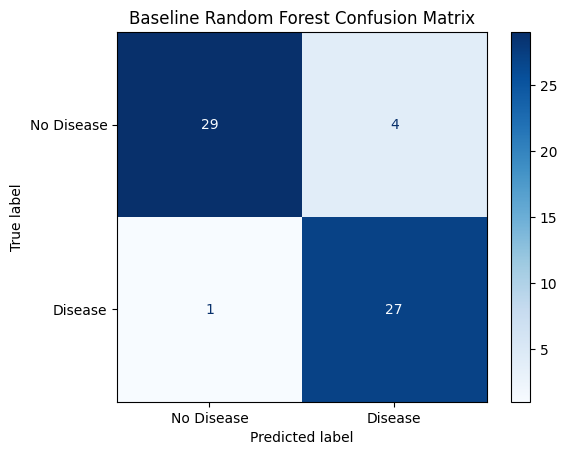

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_pred,
    display_labels=["No Disease", "Disease"],
    cmap="Blues"
)

plt.title("Baseline Random Forest Confusion Matrix")
plt.show()

Baseline ROC curve

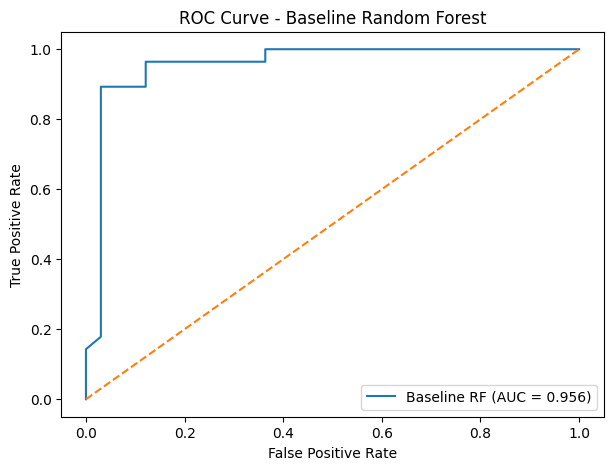

In [16]:
fpr_base, tpr_base, thresholds_base = roc_curve(
    y_test,
    baseline_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_base,
    tpr_base,
    label=f"Baseline RF (AUC = {baseline_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Random Forest")
plt.legend()
plt.show()

Bayesian Optimization of Random Forest

Now we improve the model.

Use Optuna's TPE sampler

Define the optimization objective

In [17]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [18]:
def objective(trial):

    n_estimators = trial.suggest_int(
        "n_estimators",
        100,
        700,
        step=50
    )

    max_depth = trial.suggest_int(
        "max_depth",
        3,
        20
    )

    min_samples_split = trial.suggest_int(
        "min_samples_split",
        2,
        20
    )

    min_samples_leaf = trial.suggest_int(
        "min_samples_leaf",
        1,
        10
    )

    max_features = trial.suggest_categorical(
        "max_features",
        ["sqrt", "log2", None]
    )

    classifier = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                max_features=max_features,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ])

    score = cross_val_score(
        classifier,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    return score.mean()

Run Bayesian optimization

In [19]:
sampler = optuna.samplers.TPESampler(
    seed=RANDOM_STATE
)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler
)

study.optimize(
    objective,
    n_trials=50
)

[I 2026-08-01 17:41:52,080] A new study created in memory with name: no-name-a81e054d-7678-42e6-8212-f568addffd92
[I 2026-08-01 17:42:02,194] Trial 0 finished with value: 0.8933774759861717 and parameters: {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8933774759861717.
[I 2026-08-01 17:42:11,430] Trial 1 finished with value: 0.8903105750931838 and parameters: {'n_estimators': 650, 'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8933774759861717.
[I 2026-08-01 17:42:13,468] Trial 2 finished with value: 0.8807129263651003 and parameters: {'n_estimators': 200, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 0 with value: 0.8933774759861717.
[I 2026-08-01 17:42:15,795] Trial 3 finished with value: 0.8872329763634111 and parameters: {'n_estimators': 150, 'max_depth': 8, 'min

Print optimized parameters

In [20]:
print("Best cross-validation ROC-AUC:")
print(study.best_value)

print("\nBest parameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best cross-validation ROC-AUC:
0.8947586230194926

Best parameters:
n_estimators: 450
max_depth: 20
min_samples_split: 15
min_samples_leaf: 7
max_features: sqrt


Plot optimization history

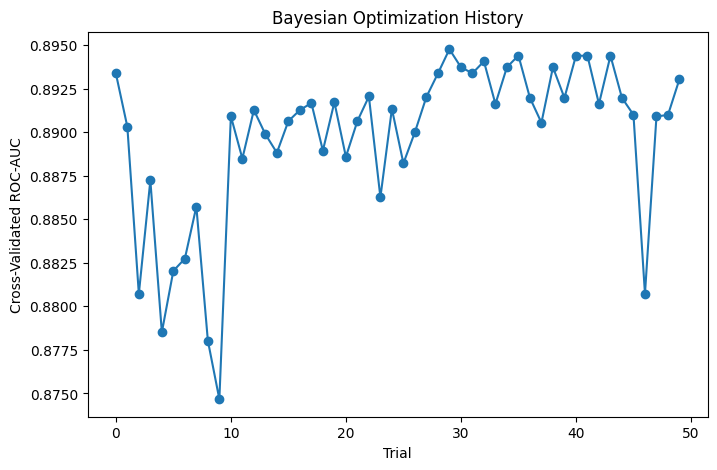

In [21]:
trial_numbers = [
    trial.number
    for trial in study.trials
    if trial.value is not None
]

trial_values = [
    trial.value
    for trial in study.trials
    if trial.value is not None
]

plt.figure(figsize=(8, 5))

plt.plot(
    trial_numbers,
    trial_values,
    marker="o",
    linestyle="-"
)

plt.xlabel("Trial")
plt.ylabel("Cross-Validated ROC-AUC")
plt.title("Bayesian Optimization History")
plt.show()

Build the optimized Random Forest

In [22]:
best_params = study.best_params

optimized_rf = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        RandomForestClassifier(
            **best_params,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

optimized_rf.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        min_samples_leaf=7,
                                        min_samples_split=15, n_estimators=450,
                                        n_jobs=-1, random_state=42))])

Evaluate optimized Random Forest

In [23]:
optimized_pred = optimized_rf.predict(X_test)

optimized_prob = optimized_rf.predict_proba(X_test)[:, 1]

optimized_accuracy = accuracy_score(
    y_test,
    optimized_pred
)

optimized_precision = precision_score(
    y_test,
    optimized_pred
)

optimized_recall = recall_score(
    y_test,
    optimized_pred
)

optimized_f1 = f1_score(
    y_test,
    optimized_pred
)

optimized_auc = roc_auc_score(
    y_test,
    optimized_prob
)

print("OPTIMIZED RANDOM FOREST")
print("-" * 40)

print(f"Accuracy : {optimized_accuracy:.4f}")
print(f"Precision: {optimized_precision:.4f}")
print(f"Recall   : {optimized_recall:.4f}")
print(f"F1 Score : {optimized_f1:.4f}")
print(f"ROC-AUC  : {optimized_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, optimized_pred))

OPTIMIZED RANDOM FOREST
----------------------------------------
Accuracy : 0.8852
Precision: 0.8387
Recall   : 0.9286
F1 Score : 0.8814
ROC-AUC  : 0.9600

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



Optimized confusion matrix

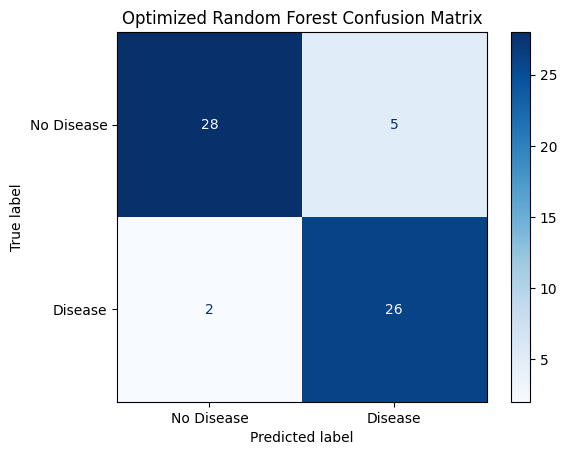

In [24]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    optimized_pred,
    display_labels=["No Disease", "Disease"],
    cmap="Blues"
)

plt.title("Optimized Random Forest Confusion Matrix")
plt.show()

Compare ROC curves

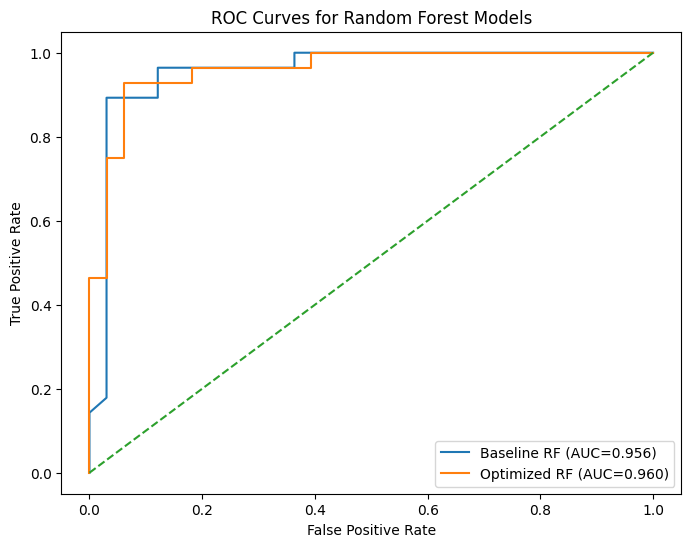

In [25]:
fpr_opt, tpr_opt, _ = roc_curve(
    y_test,
    optimized_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_base,
    tpr_base,
    label=f"Baseline RF (AUC={baseline_auc:.3f})"
)

plt.plot(
    fpr_opt,
    tpr_opt,
    label=f"Optimized RF (AUC={optimized_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Random Forest Models")
plt.legend()
plt.show()

Feature Importance

In [26]:
rf_model = optimized_rf.named_steps["model"]

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

     Feature  Importance
12      thal    0.219360
2         cp    0.159589
11        ca    0.133179
7    thalach    0.108373
9    oldpeak    0.077418
8      exang    0.070587
0        age    0.055455
10     slope    0.047634
1        sex    0.041616
4       chol    0.036998
3   trestbps    0.034171
6    restecg    0.014979
5        fbs    0.000640


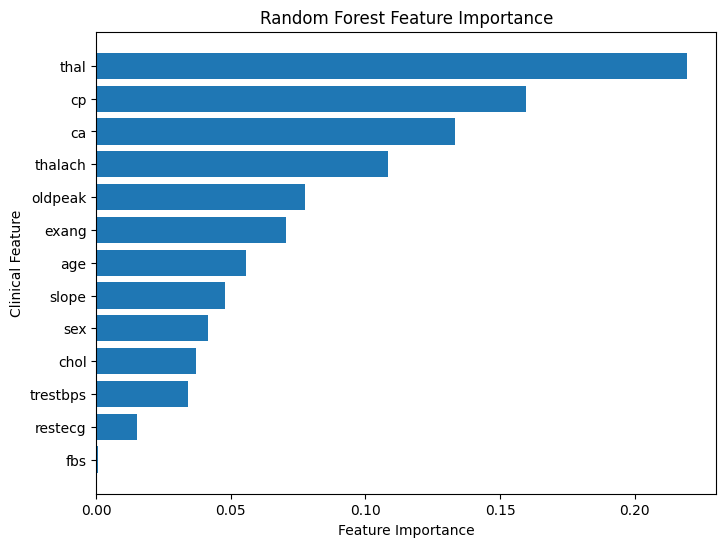

In [27]:
plt.figure(figsize=(8, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Clinical Feature")
plt.title("Random Forest Feature Importance")

plt.show()

Bayesian Prior Knowledge Integration

In [28]:
train_prevalence = y_train.mean()

print(
    f"Observed heart disease prevalence in training data: "
    f"{train_prevalence:.3f}"
)

Observed heart disease prevalence in training data: 0.459


Bayesian Logistic Regression With PyMC

Prepare data for the Bayesian model

In [29]:
imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

Standardize features

In [30]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=X_test.columns,
    index=X_test.index
)

In [31]:
X_train_np = X_train_scaled.to_numpy()
X_test_np = X_test_scaled.to_numpy()

y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

Define a prior for the intercept

In [32]:
prior_prevalence = y_train.mean()

prior_prevalence = np.clip(
    prior_prevalence,
    0.01,
    0.99
)

prior_intercept = np.log(
    prior_prevalence /
    (1 - prior_prevalence)
)

print("Training prevalence:", prior_prevalence)
print("Prior log-odds intercept:", prior_intercept)

Training prevalence: 0.45867768595041325
Prior log-odds intercept: -0.16566712188881733


Create the PyMC Bayesian model

In [33]:
coords = {
    "feature": X_train_scaled.columns
}

with pm.Model(coords=coords) as bayesian_model:

    X_data = pm.Data(
        "X_data",
        X_train_np
    )

    alpha = pm.Normal(
        "alpha",
        mu=prior_intercept,
        sigma=1.5
    )

    beta = pm.Normal(
        "beta",
        mu=0,
        sigma=1,
        dims="feature"
    )

    logits = (
        alpha +
        pm.math.dot(X_data, beta)
    )

    probability = pm.Deterministic(
        "probability",
        pm.math.sigmoid(logits)
    )

    outcome = pm.Bernoulli(
        "outcome",
        p=probability,
        observed=y_train_np
    )

    trace = pm.sample(
        draws=1500,
        tune=1500,
        chains=4,
        target_accept=0.90,
        random_seed=RANDOM_STATE,
        return_inferencedata=True
    )

Output()

Posterior summary

In [34]:
summary = az.summary(
    trace,
    var_names=["alpha", "beta"],
    round_to=3
)

print(summary)

                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha          -0.084  0.210  -0.443    0.339      0.002    0.003  8502.300   
beta[age]      -0.116  0.241  -0.545    0.355      0.003    0.003  5662.182   
beta[sex]       0.710  0.244   0.238    1.152      0.003    0.003  6646.486   
beta[cp]        0.603  0.206   0.216    0.989      0.002    0.002  7071.513   
beta[trestbps]  0.347  0.213  -0.050    0.743      0.003    0.003  6385.895   
beta[chol]      0.229  0.209  -0.151    0.637      0.002    0.003  7462.223   
beta[fbs]      -0.244  0.205  -0.628    0.141      0.003    0.002  6103.898   
beta[restecg]   0.237  0.205  -0.137    0.619      0.002    0.003  6862.197   
beta[thalach]  -0.378  0.260  -0.851    0.123      0.003    0.003  5757.048   
beta[exang]     0.408  0.216  -0.035    0.786      0.002    0.003  8036.087   
beta[oldpeak]   0.170  0.279  -0.314    0.727      0.004    0.003  5617.104   
beta[slope]     0.381  0.251  -0.109    0.845      0

Trace/convergence plots

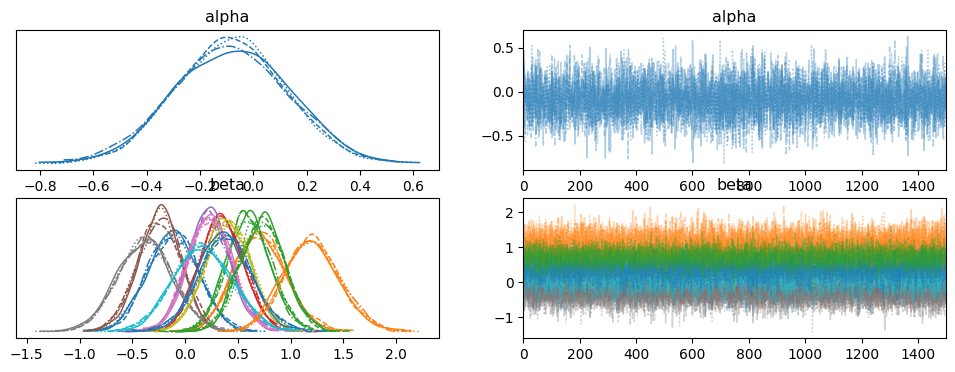

In [35]:
az.plot_trace(
    trace,
    var_names=["alpha", "beta"],
    compact=True
)

plt.show()

Posterior coefficient plot

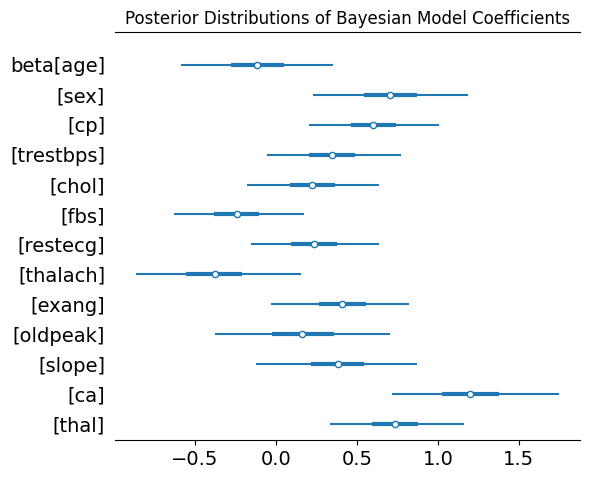

In [36]:
az.plot_forest(
    trace,
    var_names=["beta"],
    combined=True,
    hdi_prob=0.95
)

plt.title("Posterior Distributions of Bayesian Model Coefficients")
plt.show()

Generate Bayesian predictions

In [37]:
alpha_samples = (
    trace.posterior["alpha"]
    .stack(sample=("chain", "draw"))
    .values
)

beta_samples = (
    trace.posterior["beta"]
    .stack(sample=("chain", "draw"))
    .transpose("sample", "feature")
    .values
)

print(alpha_samples.shape)
print(beta_samples.shape)

(6000,)
(6000, 13)


In [38]:
test_logits = (
    alpha_samples[:, None]
    +
    beta_samples @ X_test_np.T
)

In [39]:
test_prob_samples = 1 / (
    1 + np.exp(-test_logits)
)

bayesian_prob = test_prob_samples.mean(axis=0)

In [40]:
bayesian_pred = (
    bayesian_prob >= 0.5
).astype(int)

Evaluate Bayesian model

In [41]:
bayesian_accuracy = accuracy_score(
    y_test,
    bayesian_pred
)

bayesian_precision = precision_score(
    y_test,
    bayesian_pred
)

bayesian_recall = recall_score(
    y_test,
    bayesian_pred
)

bayesian_f1 = f1_score(
    y_test,
    bayesian_pred
)

bayesian_auc = roc_auc_score(
    y_test,
    bayesian_prob
)

print("BAYESIAN LOGISTIC REGRESSION")
print("-" * 40)

print(f"Accuracy : {bayesian_accuracy:.4f}")
print(f"Precision: {bayesian_precision:.4f}")
print(f"Recall   : {bayesian_recall:.4f}")
print(f"F1 Score : {bayesian_f1:.4f}")
print(f"ROC-AUC  : {bayesian_auc:.4f}")

BAYESIAN LOGISTIC REGRESSION
----------------------------------------
Accuracy : 0.8689
Precision: 0.8125
Recall   : 0.9286
F1 Score : 0.8667
ROC-AUC  : 0.9513


Bayesian confusion matrix

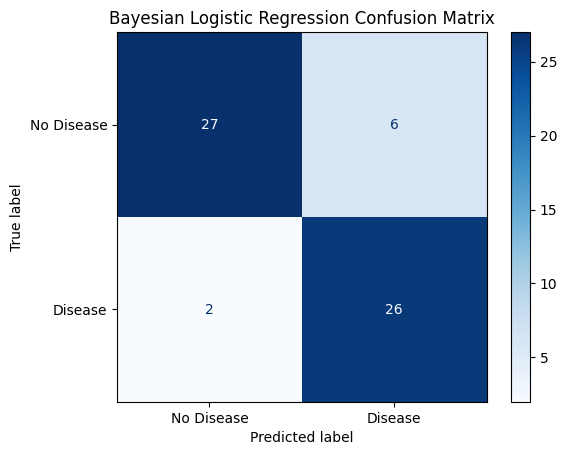

In [42]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    bayesian_pred,
    display_labels=["No Disease", "Disease"],
    cmap="Blues"
)

plt.title("Bayesian Logistic Regression Confusion Matrix")
plt.show()

All-model ROC curve

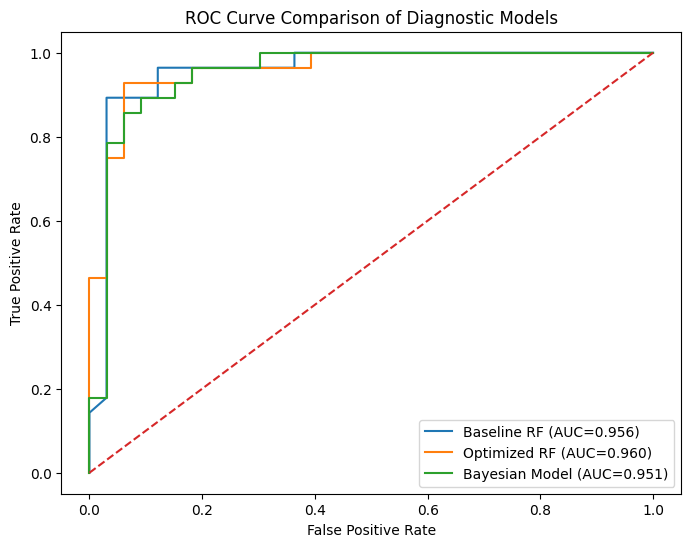

In [43]:
fpr_bayes, tpr_bayes, _ = roc_curve(
    y_test,
    bayesian_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_base,
    tpr_base,
    label=f"Baseline RF (AUC={baseline_auc:.3f})"
)

plt.plot(
    fpr_opt,
    tpr_opt,
    label=f"Optimized RF (AUC={optimized_auc:.3f})"
)

plt.plot(
    fpr_bayes,
    tpr_bayes,
    label=f"Bayesian Model (AUC={bayesian_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison of Diagnostic Models"
)

plt.legend()
plt.show()

Final comparison table

In [44]:
results = pd.DataFrame({

    "Model": [
        "Baseline Random Forest",
        "Bayesian-Optimized Random Forest",
        "Bayesian Logistic Regression"
    ],

    "Accuracy": [
        baseline_accuracy,
        optimized_accuracy,
        bayesian_accuracy
    ],

    "Precision": [
        baseline_precision,
        optimized_precision,
        bayesian_precision
    ],

    "Recall": [
        baseline_recall,
        optimized_recall,
        bayesian_recall
    ],

    "F1 Score": [
        baseline_f1,
        optimized_f1,
        bayesian_f1
    ],

    "ROC-AUC": [
        baseline_auc,
        optimized_auc,
        bayesian_auc
    ]
})

print(
    results.round(4).to_string(index=False)
)

                           Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
          Baseline Random Forest    0.9180     0.8710  0.9643    0.9153   0.9562
Bayesian-Optimized Random Forest    0.8852     0.8387  0.9286    0.8814   0.9600
    Bayesian Logistic Regression    0.8689     0.8125  0.9286    0.8667   0.9513


Demonstrating Bayesian Updating for a New Patient

In [45]:
patient_index = 0

patient = X_test_np[patient_index]

true_diagnosis = y_test_np[patient_index]

patient_logits = (
    alpha_samples +
    beta_samples @ patient
)

patient_prob_samples = (
    1 /
    (
        1 + np.exp(-patient_logits)
    )
)

patient_mean_probability = patient_prob_samples.mean()

patient_lower = np.quantile(
    patient_prob_samples,
    0.025
)

patient_upper = np.quantile(
    patient_prob_samples,
    0.975
)

print(
    f"True diagnosis: {true_diagnosis}"
)

print(
    f"Posterior mean disease probability: "
    f"{patient_mean_probability:.3f}"
)

print(
    "95% credible interval: "
    f"[{patient_lower:.3f}, "
    f"{patient_upper:.3f}]"
)

True diagnosis: 0
Posterior mean disease probability: 0.220
95% credible interval: [0.067, 0.461]


Plot Patient Posterior Probability

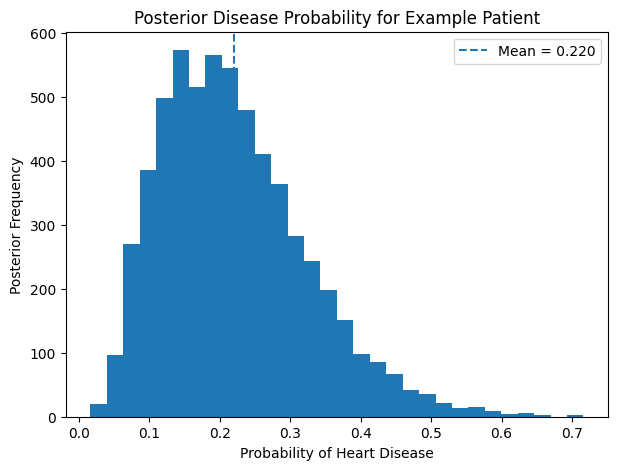

In [46]:
plt.figure(figsize=(7, 5))

plt.hist(
    patient_prob_samples,
    bins=30
)

plt.axvline(
    patient_mean_probability,
    linestyle="--",
    label=f"Mean = {patient_mean_probability:.3f}"
)

plt.xlabel("Probability of Heart Disease")
plt.ylabel("Posterior Frequency")

plt.title(
    "Posterior Disease Probability for Example Patient"
)

plt.legend()
plt.show()